In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/game_info.csv')
print(df.shape)
df.head()

(474417, 27)


,id,slug,name,metacritic,released,tba,updated,website,rating,rating_top,...,developers,genres,publishers,esrb_rating,added_status_yet,added_status_owned,added_status_beaten,added_status_toplay,added_status_dropped,added_status_playing
0,1,dgeneration-hd,D/Generation HD,NaN,2015-10-23,False,2019-09-17T11:58:57,http://dgeneration.net,0.0,0,...,West Coast Software,Adventure||Puzzle,West Coast Software,Everyone 10+,4,88,2,2,0,0
1,10,g-prime,G Prime Into The Rain,NaN,2016-01-06,False,2019-11-06T23:04:19,NaN,0.0,0,...,Soma Games,Simulation||Indie,Immanitas Entertainment||Code-Monkeys,Everyone,2,42,2,0,0,0
2,100,land-sliders,Land Sliders,NaN,2015-09-24,False,2019-10-22T13:56:16,http://prettygreat.com,0.0,0,...,Prettygreat Pty,Adventure||Arcade,Prettygreat Pty,Everyone 10+,0,2,2,0,1,0
3,1000,pixel-gear,Pixel Gear,NaN,2016-10-20,False,2019-08-28T22:16:02,https://www.facebook.com/Geronimo-Interactive-...,0.0,0,...,Oasis Games||Geronimo Interactive,Action||Indie,Geronimo Interactive,Teen,0,1,0,0,0,0
4,10000,gods-and-idols,Gods and Idols,NaN,2016-12-12,False,2019-09-17T13:37:13,http://www.godsandidols.com/,0.0,1,...,Viking Tao,RPG||Strategy||Massively Multiplayer,Viking Tao,NaN,2,79,0,0,0,0


In [4]:
print(df.columns.tolist())

['id', 'slug', 'name', 'metacritic', 'released', 'tba', 'updated', 'website', 'rating', 'rating_top', 'playtime', 'achievements_count', 'ratings_count', 'suggestions_count', 'game_series_count', 'reviews_count', 'platforms', 'developers', 'genres', 'publishers', 'esrb_rating', 'added_status_yet', 'added_status_owned', 'added_status_beaten', 'added_status_toplay', 'added_status_dropped', 'added_status_playing']


In [5]:
print(df.isnull().sum().sort_values(ascending=False))

metacritic              469684
esrb_rating             418553
website                 409376
publishers              333401
genres                  103185
released                 24199
developers                8366
platforms                 3986
name                         3
slug                         2
id                           0
playtime                     0
rating_top                   0
rating                       0
updated                      0
tba                          0
suggestions_count            0
game_series_count            0
achievements_count           0
reviews_count                0
ratings_count                0
added_status_yet             0
added_status_owned           0
added_status_beaten          0
added_status_toplay          0
added_status_dropped         0
added_status_playing         0
dtype: int64


In [6]:
df_scored = df[df['metacritic'].notna()].copy()
print(f"Games with Metacritic scores: {len(df_scored)}")
print(f"Metacritic score distribution:")
print(df_scored['metacritic'].describe())


Games with Metacritic scores: 4733
Metacritic score distribution:
count    4733.000000
mean       73.159307
std        11.502213
min        15.000000
25%        67.000000
50%        75.000000
75%        81.000000
max        99.000000
Name: metacritic, dtype: float64


In [7]:
df_scored['success'] = (df_scored['metacritic'] >= 75).astype(int)

print(df_scored['success'].value_counts())
print(f"\nSuccess rate: {df_scored['success'].mean():.1%}")

success
1    2396
0    2337
Name: count, dtype: int64

Success rate: 50.6%


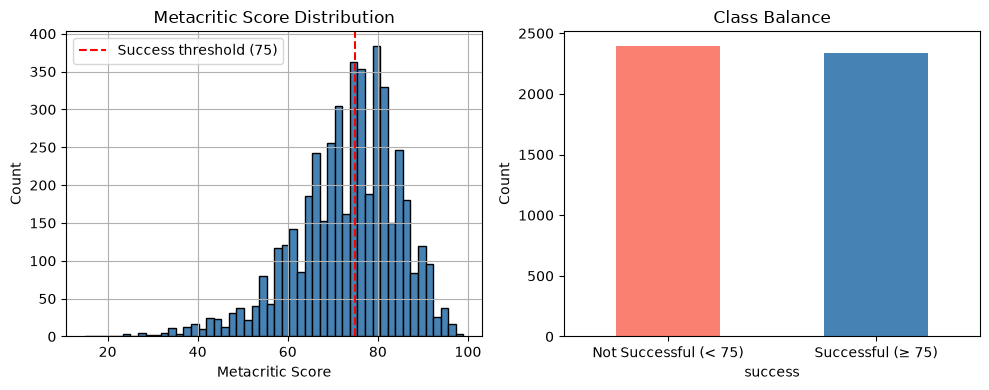

In [8]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
df_scored['metacritic'].hist(bins=50, color='steelblue', edgecolor='black')
plt.axvline(75, color='red', linestyle='--', label='Success threshold (75)')
plt.xlabel('Metacritic Score')
plt.ylabel('Count')
plt.title('Metacritic Score Distribution')
plt.legend()

plt.subplot(1, 2, 2)
df_scored['success'].value_counts().plot(kind='bar', color=['salmon', 'steelblue'])
plt.xticks([0, 1], ['Not Successful (< 75)', 'Successful (≥ 75)'], rotation=0)
plt.title('Class Balance')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [9]:
# Extract release year
df_scored['release_year'] = pd.to_datetime(df_scored['released'], errors='coerce').dt.year

# Parse genres (pipe-separated) — take the first genre as primary
df_scored['primary_genre'] = df_scored['genres'].fillna('Unknown').apply(
    lambda x: x.split('||')[0]
)

# Count number of genres (breadth signal)
df_scored['genre_count'] = df_scored['genres'].fillna('').apply(
    lambda x: len(x.split('||')) if x else 0
)

# Count number of platforms
df_scored['platform_count'] = df_scored['platforms'].fillna('').apply(
    lambda x: len(x.split('||')) if x else 0
)

# Publisher tier — is it a known major publisher?
major_publishers = ['Electronic Arts', 'Ubisoft', 'Activision', 'Nintendo',
                    'Sony', 'Microsoft', 'Sega', 'Bethesda', 'Square Enix',
                    'Rockstar Games', '2K Games', 'Capcom', 'Bandai Namco']

df_scored['is_major_publisher'] = df_scored['publishers'].fillna('').apply(
    lambda x: int(any(pub in x for pub in major_publishers))
)

print(df_scored[['primary_genre', 'genre_count', 'platform_count', 
                  'is_major_publisher', 'release_year']].head(10))

    primary_genre  genre_count  platform_count  is_major_publisher  \
43         Action            3               4                   0   
85         Action            2               5                   0   
207        Action            3               2                   0   
249           RPG            2               4                   0   
291        Action            4               2                   0   
300        Action            3               3                   1   
359        Action            2               5                   1   
379      Strategy            1               3                   0   
401           RPG            1               3                   0   
413      Strategy            2               4                   0   

     release_year  
43         2017.0  
85         2017.0  
207        2016.0  
249        2014.0  
291        2013.0  
300        2017.0  
359        2017.0  
379        2013.0  
401        2016.0  
413        2016.0  


In [10]:
print("Top 15 genres:")
print(df_scored['primary_genre'].value_counts().head(15))

Top 15 genres:
primary_genre
Action        2544
Adventure      673
Strategy       488
RPG            365
Simulation     142
Sports         118
Racing          95
Arcade          48
Unknown         47
Shooter         44
Casual          39
Indie           32
Platformer      32
Fighting        28
Puzzle          23
Name: count, dtype: int64


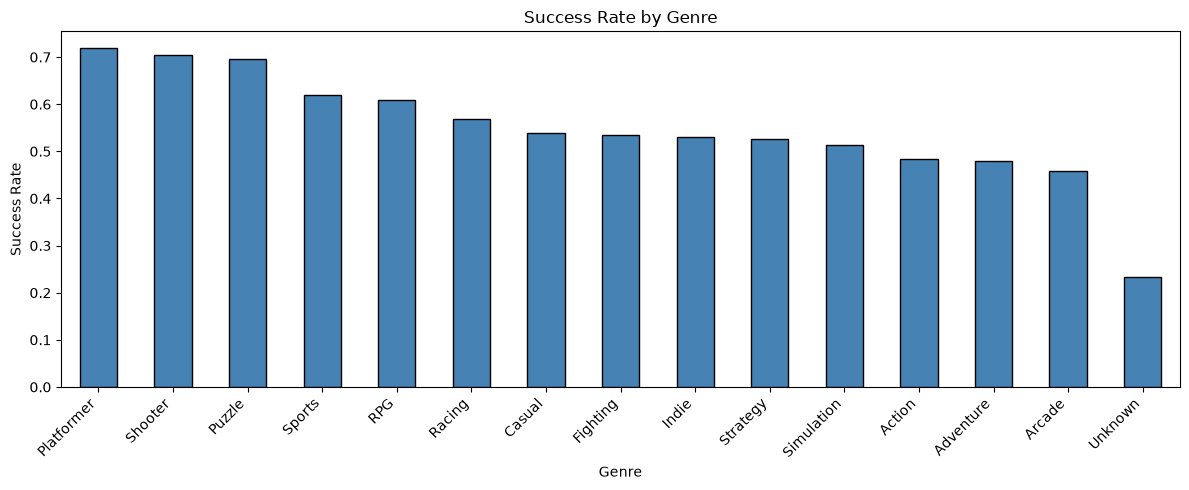

In [11]:
genre_success = df_scored.groupby('primary_genre')['success'].agg(['mean', 'count'])
genre_success = genre_success[genre_success['count'] >= 20].sort_values('mean', ascending=False)

plt.figure(figsize=(12, 5))
genre_success['mean'].plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Success Rate by Genre')
plt.ylabel('Success Rate')
plt.xlabel('Genre')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [12]:
from sklearn.preprocessing import LabelEncoder

# Select features
feature_df = df_scored[[
    'primary_genre', 'genre_count', 'platform_count',
    'is_major_publisher', 'release_year', 'playtime',
    'ratings_count', 'reviews_count', 'added_status_owned'
]].copy()

# Fill remaining nulls
feature_df['release_year'] = feature_df['release_year'].fillna(feature_df['release_year'].median())

# Encode primary_genre as integer
le = LabelEncoder()
feature_df['genre_encoded'] = le.fit_transform(feature_df['primary_genre'])
feature_df = feature_df.drop('primary_genre', axis=1)

X = feature_df
y = df_scored['success']

print(X.shape)
print(X.isnull().sum())

(4733, 9)
genre_count           0
platform_count        0
is_major_publisher    0
release_year          0
playtime              0
ratings_count         0
reviews_count         0
added_status_owned    0
genre_encoded         0
dtype: int64


In [13]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")

              precision    recall  f1-score   support

           0       0.68      0.73      0.71       468
           1       0.72      0.67      0.69       479

    accuracy                           0.70       947
   macro avg       0.70      0.70      0.70       947
weighted avg       0.70      0.70      0.70       947

AUC-ROC: 0.7623


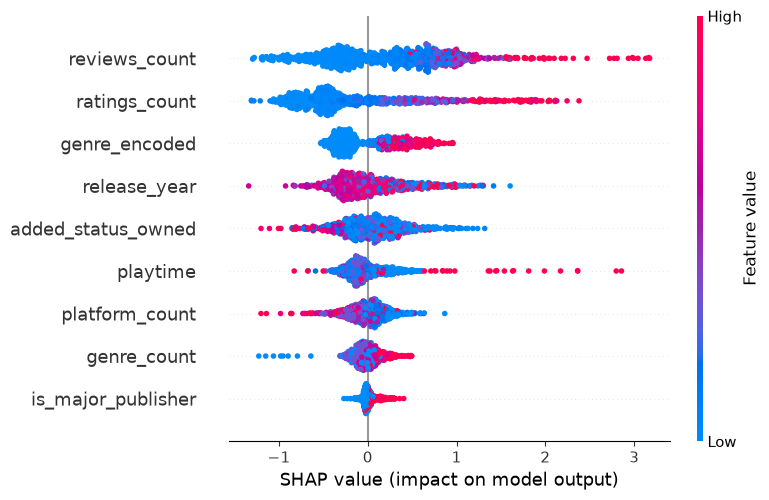

In [14]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist())

In [15]:
import joblib
import os

os.makedirs('../ml', exist_ok=True)

joblib.dump(model, '../ml/model.joblib')
joblib.dump(le, '../ml/label_encoder.joblib')
joblib.dump(list(X.columns), '../ml/feature_columns.joblib')

print("Model, encoder, and feature columns saved.")

Model, encoder, and feature columns saved.


In [16]:
loaded_model = joblib.load('../ml/model.joblib')
loaded_le = joblib.load('../ml/label_encoder.joblib')
loaded_cols = joblib.load('../ml/feature_columns.joblib')

# Simulate a test prediction — an Action game, 3 genres, 4 platforms, not major publisher
test_input = {
    'genre_count': 3,
    'platform_count': 4,
    'is_major_publisher': 0,
    'release_year': 2022,
    'playtime': 10,
    'ratings_count': 500,
    'reviews_count': 50,
    'added_status_owned': 200,
    'genre_encoded': loaded_le.transform(['Action'])[0]
}

import pandas as pd
test_df = pd.DataFrame([test_input])[loaded_cols]
prob = loaded_model.predict_proba(test_df)[0][1]
print(f"Predicted success probability: {prob:.1%}")

Predicted success probability: 88.9%
